In [1]:
import torch
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from torch import nn
import matplotlib.pyplot as plt

In [2]:
transforms = v2.Compose([v2.ToImage(), 
                         v2.ToDtype(dtype=torch.float32, scale=True), #pushes value to [0,1]
                         #now push the value to [-1,1] range. important for convolution to be more balanced
                         v2.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))]) 

train_data = CIFAR10(
    root="../Datasets",
    train=True,
    transform=transforms,
    download=True
)

test_data = CIFAR10(
    root="../Datasets",
    train=False,
    transform=transforms,
    download=True
)

In [12]:
train_loader = DataLoader(dataset=train_data, batch_size=64, num_workers=2)
test_loader = DataLoader(dataset=test_data, batch_size=64, num_workers=2)

In [13]:
train_n = len(train_loader.dataset)
test_n = len(test_loader.dataset)
(train_n, test_n)

(50000, 10000)

In [5]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [6]:
sample_image = train_loader.dataset[0]
image = sample_image[0]
target = sample_image[1]
print(f"{type(image)=},\n{image.shape=},\n{target=}")

type(image)=<class 'torchvision.tv_tensors._image.Image'>,
image.shape=torch.Size([3, 32, 32]),
target=6


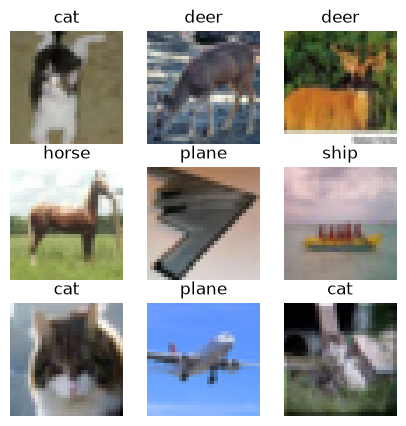

In [7]:
plt.figure(figsize=(5,5))
idx = torch.randint(low=0, high=train_n, size=(9,))

for i in range(9):
    plt.subplot(3,3,i+1)
    img_idx = idx[i]
    img = train_loader.dataset[img_idx][0]
    target = train_loader.dataset[img_idx][1]
    img = img / 2 + 0.5 #unnormalize
    img = torch.permute(img, dims=(1,2,0))
    plt.title(classes[target])
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [8]:
class Net(nn.Module):
    def __init__(self) -> None:
        super().__init__()  
        
        # image input 3x32x32
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5), # output shape 6x28x28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # output shape 6x14x14
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=5), # output shape 16x10x10
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # output shape 16x5x5
        )
        
        self.flatten1 = nn.Flatten(start_dim=1) # output shape 400
        
        self.linear_block = nn.Sequential(
            nn.Linear(in_features=16*5*5, out_features=120),
            nn.ReLU(),
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(),
            nn.Linear(in_features=84, out_features=10)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.flatten1(x)
        x = self.linear_block(x)
        return x

In [9]:
net = Net()
net

Net(
  (conv_block1): Sequential(
    (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten1): Flatten(start_dim=1, end_dim=-1)
  (linear_block): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=84, bias=True)
    (3): ReLU()
    (4): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [10]:
net(train_loader.dataset[0][0].unsqueeze(dim=0)).argmax(dim=1)

tensor([5])

In [ ]:
net = Net()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)
epochs = 2

for i in range(epochs):
    running_loss = 0.0
    
    for batch, (x, y) in enumerate(train_loader):
        optimizer.zero_grad()
        
        logits = net(x)
        loss = loss_fn(logits, y)
        loss.backward()
        
        optimizer.step()
        running_loss += loss.item()
    
        if batch !=0 and batch%100 == 0: #for every 100 rows
            print(f"Epoch {i}, {batch} --> Loss {running_loss/100:.4f}") #mini batch loss
            running_loss = 0.0

Epoch 0, 100 --> Loss 2.3261
Epoch 0, 200 --> Loss 2.3011
Epoch 0, 300 --> Loss 2.2995
Epoch 0, 400 --> Loss 2.2965
Epoch 0, 500 --> Loss 2.2916
Epoch 0, 600 --> Loss 2.2812
Epoch 0, 700 --> Loss 2.2599
Epoch 1, 100 --> Loss 2.2252
Epoch 1, 200 --> Loss 2.1850
Epoch 1, 300 --> Loss 2.1753
Epoch 1, 400 --> Loss 2.1277
Epoch 1, 500 --> Loss 2.1233
Epoch 1, 600 --> Loss 2.0997
Epoch 1, 700 --> Loss 2.0785
